In [1]:
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
import numpy as np
import os
import shutil
import zipfile
from sklearn.model_selection import KFold

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
dataset_path = '/content/drive/MyDrive/RiceLeafsDisease.zip'

In [12]:

from sklearn.model_selection import train_test_split


zip_file_path = '/content/drive/MyDrive/RiceLeafsDisease.zip'
extracted_dir = '/content/RiceLeafsDisease'
output_dir = '/content/organized_dataset'


with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_dir)


print("Extracted directory structure:")
for root, dirs, files in os.walk(extracted_dir):
    print("Root:", root)
    print("Directories:", dirs)
    print("Files:", files)
    print("-" * 40)

for split in ['train', 'validation', 'test']:
    for class_name in ['bacterial_leaf_blight', 'healthy', 'leaf_blast', 'leaf_scald']:
        os.makedirs(os.path.join(output_dir, split, class_name), exist_ok=True)

images = []
labels = []

for class_name in ['bacterial_leaf_blight', 'healthy', 'leaf_blast', 'leaf_scald']:
    class_dir = None
    for root, dirs, files in os.walk(extracted_dir):
        if class_name in dirs:
            class_dir = os.path.join(root, class_name)
            break

    if class_dir is None:
        print(f"Warning: Directory for class '{class_name}' not found. Skipping...")
        continue

    for img in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img)
        if os.path.isfile(img_path):
            images.append(img_path)
            labels.append(class_name)

print(f"Total images found: {len(images)}")

if len(images) == 0:
    raise ValueError("No images found in the dataset. Please check the dataset structure.")

train_images, temp_images, train_labels, temp_labels = train_test_split(
    images, labels, test_size=0.3, stratify=labels, random_state=42
)
val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

def move_images(image_list, labels_list, split):
    for img, label in zip(image_list, labels_list):
        dest_dir = os.path.join(output_dir, split, label)
        shutil.copy(img, dest_dir)

move_images(train_images, train_labels, 'train')
move_images(val_images, val_labels, 'validation')
move_images(test_images, test_labels, 'test')

print("Data has been organized successfully.")
print(f"Train set: {len(train_images)} images")
print(f"Validation set: {len(val_images)} images")
print(f"Test set: {len(test_images)} images")


Extracted directory structure:
Root: /content/RiceLeafsDisease
Directories: ['RiceLeafsDisease']
Files: []
----------------------------------------
Root: /content/RiceLeafsDisease/RiceLeafsDisease
Directories: ['leaf_blast', 'bacterial_leaf_blight', 'healthy', 'leaf_scald']
Files: ['desktop.ini']
----------------------------------------
Root: /content/RiceLeafsDisease/RiceLeafsDisease/leaf_blast
Directories: []
Files: ['leaf_blast (94).jpg', 'leaf_blast (206).jpg', 'Leaf_blast  (274).jpg', 'leaf_blast (81).jpg', 'leaf_blast (62).jpg', 'leaf_blast (136).jpg', 'Leaf_blast  (36).jpg', 'leaf_blast (229).jpg', 'leaf_blast (11).jpg', 'Leaf_blast  (905).jpg', 'leaf_blast (290).jpg', 'leaf_blast (155).jpg', 'leaf_blast (167).jpg', 'Leaf_blast  (562).jpg', 'Leaf_blast  (148).jpg', 'Leaf_blast  (491).jpg', 'Leaf_blast  (765).jpg', 'Leaf_blast  (667).jpg', 'leaf_blast (315).jpg', 'leaf_blast (201).jpg', 'leaf_blast (211).jpg', 'Leaf_blast  (316).jpg', 'leaf_blast (110).jpg', 'Leaf_blast  (806).jp

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_dir = os.path.join(output_dir, 'train')
validation_dir = os.path.join(output_dir, 'validation')

datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)


test_dir = os.path.join(output_dir, 'test')
test_datagen = ImageDataGenerator(rescale=1.0/255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 1376 images belonging to 4 classes.
Found 295 images belonging to 4 classes.
Found 296 images belonging to 4 classes.


In [18]:


base_model = MobileNetV2(input_shape=(150, 150, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


<ipython-input-18-a921678decfd>:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(150, 150, 3), include_top=False, weights='imagenet')


In [19]:
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator
)


Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.5322 - loss: 4.7817 - val_accuracy: 0.6814 - val_loss: 0.6968
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.6855 - loss: 0.6816 - val_accuracy: 0.7661 - val_loss: 0.6163
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.7751 - loss: 0.4970 - val_accuracy: 0.7797 - val_loss: 0.5163
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.8305 - loss: 0.4546 - val_accuracy: 0.8000 - val_loss: 0.5210
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.8196 - loss: 0.4199 - val_accuracy: 0.8102 - val_loss: 0.4619
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.8559 - loss: 0.3475 - val_accuracy: 0.8271 - val_loss: 0.4255
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.8568 - loss: 0.3556 - val_accuracy: 0.8237 - val_loss: 0.4515
Epoch 8/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.8639 - loss: 0.3203 - val_accuracy: 0.8339 - val_loss:

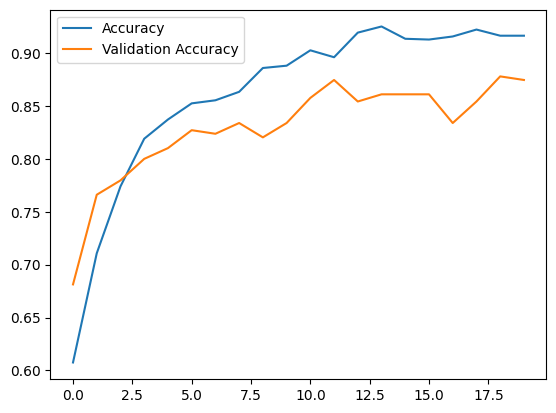

In [20]:


plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()


In [21]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 911ms/step - accuracy: 0.8972 - loss: 0.3290
Test Accuracy: 90.20%


10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 860ms/step


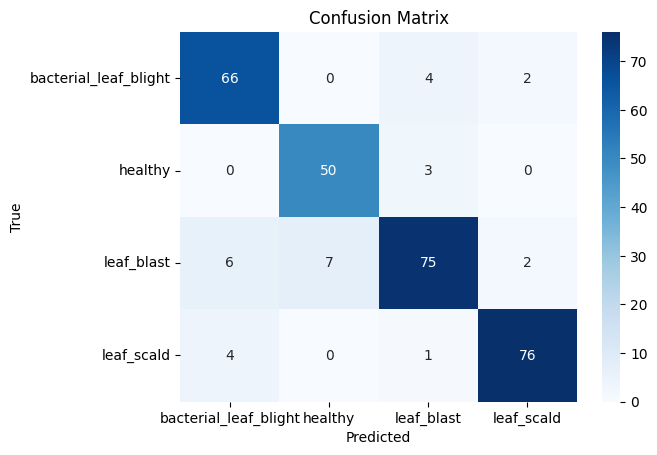

                       precision    recall  f1-score   support

bacterial_leaf_blight       0.87      0.92      0.89        72
              healthy       0.88      0.94      0.91        53
           leaf_blast       0.90      0.83      0.87        90
           leaf_scald       0.95      0.94      0.94        81

             accuracy                           0.90       296
            macro avg       0.90      0.91      0.90       296
         weighted avg       0.90      0.90      0.90       296



In [22]:
!pip install seaborn
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report # Import confusion_matrix and classification_report

y_true = test_generator.classes
y_pred = np.argmax(model.predict(test_generator), axis=1)

conf_matrix = confusion_matrix(y_true, y_pred)  # Now confusion_matrix is defined
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(test_generator.class_indices.keys()),
            yticklabels=list(test_generator.class_indices.keys()))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))

In [24]:
# Save the trained model
model.save('/content/rice_disease_model.h5')
print("Model saved as rice_disease_model.h5")


Model saved as rice_disease_model.h5


In [26]:
from tensorflow.keras.preprocessing import image  # Import the 'image' module

def classify_image(img_path, model, class_labels, threshold=0.75):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(150, 150))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Make prediction
    predictions = model.predict(img_array)
    confidence = np.max(predictions)  # Get highest probability
    predicted_class = class_labels[np.argmax(predictions)]

    if confidence < threshold:  # Check confidence threshold
        return "Cannot recognize or not a trained disease."

    return f"Predicted class: {predicted_class} ({confidence * 100:.2f}%)"

# Example usage
# Check if the file exists before trying to load it
import os
img_path = '/content/organized_dataset/test/leaf_blast/Leaf_blast  (1080).jpg'
if not os.path.exists(img_path):
    print(f"Error: Image file not found at {img_path}")
else:
    result = classify_image(img_path, model, list(train_generator.class_indices.keys()))
    print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted class: leaf_blast (82.59%)


In [27]:
from tensorflow.keras.preprocessing import image

def visualize_prediction(img_path, model, class_labels, true_label=None, threshold=0.75):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(150, 150))  # Match your model's input size
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Make prediction
    prediction = model.predict(img_array)
    confidence = np.max(prediction)  # Get highest probability
    predicted_class = class_labels[np.argmax(prediction)]

    plt.imshow(image.load_img(img_path))
    plt.axis('off')

    if confidence < threshold:
        plt.title("Cannot recognize or not a trained disease.", fontsize=12)
    else:
        plt.title(f"Predicted: {predicted_class} ({confidence * 100:.2f}%)\n"
                  f"True: {true_label if true_label else 'Unknown'}", fontsize=12)

    plt.show()




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


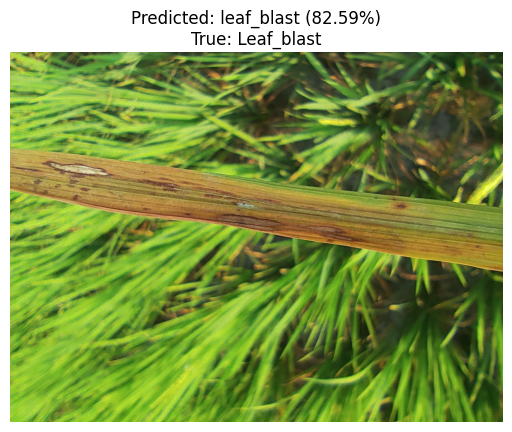

In [28]:

img_path = '/content/organized_dataset/test/leaf_blast/Leaf_blast  (1080).jpg'
true_label = 'Leaf_blast'  # Set the true label of the image
visualize_prediction(img_path, model, list(train_generator.class_indices.keys()), true_label)